# Relazione – Laboratori di Data Science (Algebra Lineare)

Questa relazione raccoglie lo svolgimento degli esercizi del **Foglio 2 – Discesa del gradiente e Regressione Polinomiale** 
del corso di Data Science (Laurea in Fisica, Alma Mater Studiorum – Università di Bologna, 
a.a. 2025/2026).

Per tutto il codice, si rimanda alla repository GitHub:  
🔗 [Laboratori-Data-Science](https://github.com/CetrioloRiick/Laboratori-Data-Science.git)


In [2]:
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

## Esercizio 1

### 1

bla bla bla

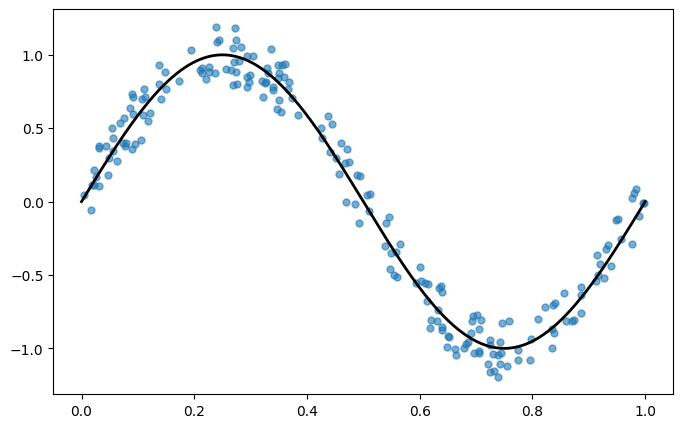

In [3]:
epsilon = 0.2
n = 200

x = np.random.uniform(0, 1, n)
noise = np.random.uniform(-epsilon, epsilon, n)
y = np.sin(2 * np.pi * x) + noise

x_true = np.linspace(0, 1, 500)
y_true = np.sin(2 * np.pi * x_true)


plt.figure(figsize=(8, 5))
plt.scatter(x, y, s=25, alpha=0.6, label="Punti con rumore")
plt.plot(x_true, y_true, color="black", lw=2, label="sin(2πx)")

### 2

blablabla

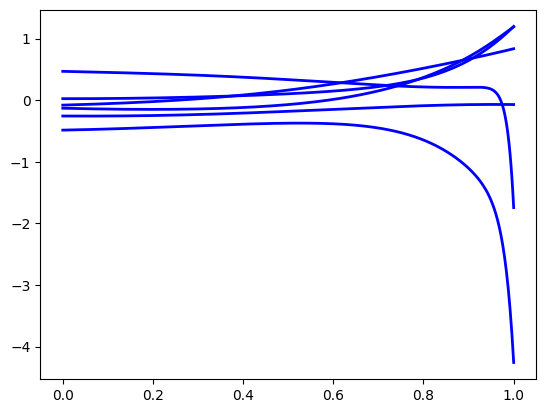

In [9]:
def polynomial_model(coeffs, x):
    x = np.asarray(x)
    powers = x[:, None] ** np.arange(len(coeffs))
    return powers @ coeffs


degrees = [5, 9, 18, 30, 60, 100]
coeffs = [np.random.uniform(-0.5, 0.5, deg) for deg in degrees]
for c in coeffs:
    pippo = polynomial_model(c, x_true)
    plt.plot(x_true, pippo, color="blue", lw=2, label="model")

### 3 & 4

blablabla

In [12]:
def cost_function(coeffs: np.ndarray, x: np.ndarray, y: np.ndarray) -> float:
    predictions = polynomial_model(coeffs, x)
    errors = predictions - y
    return np.mean(errors**2) / 2


def gradient_cost_function(
    coeffs: np.ndarray, x: np.ndarray, y: np.ndarray
) -> np.ndarray:
    predictions = polynomial_model(coeffs, x)
    errors = predictions - y
    N = len(x)

    gradient = np.array([np.sum(errors * x**i) / N for i in range(len(coeffs))])
    return gradient

coeff = np.random.uniform(-0.5, 0.5, 18) 
with tqdm(range(15000), desc="Ottimizzazione", unit="iter") as t:
    for i in t:
        grad = gradient_cost_function(coeff, x, y)
        costo = cost_function(coeff, x, y)
        t.set_postfix({"Costo": f"{costo:.5f}"})
        for i, g in enumerate(grad):
            coeff[i] -= 0.1 * g
pippo = polynomial_model(coeff, x_true)

plt.plot(x_true, pippo, color="blue", lw=2, label="model")


Ottimizzazione:   0%|                                                                                        | 0/15000 [00:00<?, ?iter/s]


TypeError: object of type 'numpy.float64' has no len()

## Esercizio 2

### 2a

Il codice analizza come variano autovalori e valori singolari di una matrice quasi triangolare al variare di un piccolo parametro epsilon.
Quando epsilon = 0 la matrice risulta degenere, con autovalori nulli e non definiti in modo stabile, mentre i valori singolari restano ben determinati e positivi.
Al crescere (in valore assoluto) di epsilon, gli autovalori si separano e assumono valori complessi con moduli differenti, mostrando una forte sensibilità alla perturbazione.
Questo evidenzia come gli autovalori dipendano in modo discontinuo da piccole variazioni della matrice, mentre i valori singolari, legati alla norma e quindi sempre reali e non negativi, risultano più stabili numericamente.


In [5]:
import numpy as np
import matplotlib.pyplot as plt

epsilon_range = np.linspace(-2e-5, 2e-5, 21)

for epsilon in epsilon_range:
    matrix = np.array(
        [
            [0.0, 1.0, 0.0, 0.0],
            [0.0, 0.0, 2.0, 0.0],
            [0.0, 0.0, 0.0, 3.0],
            [epsilon, 0.0, 0.0, 0.0],
        ]
    )

    eigenvalues = np.linalg.eigvals(matrix)
    singular_values = np.linalg.svdvals(matrix)

    print("=" * 60)
    print(f"ε = {epsilon:.2e}")
    print(f"Eigenvalues      : {np.round(eigenvalues, 6)}")
    print(f"Singular values  : {np.round(singular_values, 6)}")


ε = -1.00e-04
Eigenvalues      : [-0.110668+0.110668j -0.110668-0.110668j  0.110668+0.110668j
  0.110668-0.110668j]
Singular values  : [3.e+00 2.e+00 1.e+00 1.e-04]
ε = -9.00e-05
Eigenvalues      : [-0.107791+0.107791j -0.107791-0.107791j  0.107791+0.107791j
  0.107791-0.107791j]
Singular values  : [3.e+00 2.e+00 1.e+00 9.e-05]
ε = -8.00e-05
Eigenvalues      : [-0.104664+0.104664j -0.104664-0.104664j  0.104664+0.104664j
  0.104664-0.104664j]
Singular values  : [3.e+00 2.e+00 1.e+00 8.e-05]
ε = -7.00e-05
Eigenvalues      : [-0.101227+0.101227j -0.101227-0.101227j  0.101227+0.101227j
  0.101227-0.101227j]
Singular values  : [3.e+00 2.e+00 1.e+00 7.e-05]
ε = -6.00e-05
Eigenvalues      : [-0.0974+0.0974j -0.0974-0.0974j  0.0974+0.0974j  0.0974-0.0974j]
Singular values  : [3.e+00 2.e+00 1.e+00 6.e-05]
ε = -5.00e-05
Eigenvalues      : [-0.09306+0.09306j -0.09306-0.09306j  0.09306+0.09306j  0.09306-0.09306j]
Singular values  : [3.e+00 2.e+00 1.e+00 5.e-05]
ε = -4.00e-05
Eigenvalues      : [-0

### 2c

Come si osserva dal grafico delle energie cumulative, intorno all’indice 150 è già conservata oltre la metà dell’energia totale. Scendendo sotto tale soglia, la perdita di informazione diventa rapidamente evidente, con immagini sempre più sgranate e prive di dettaglio.
Il codice ricostruisce progressivamente la matrice dell’immagine utilizzando un numero crescente di valori singolari r, mostrando in ciascun subplot la versione compressa corrispondente.
Si nota come, aumentando r, la qualità visiva migliori in modo non lineare: i primi autovalori catturano le strutture principali dell’immagine, mentre i successivi aggiungono solo dettagli fini.
Questo conferma che la decomposizione SVD consente una compressione efficace, mantenendo gran parte dell’informazione visiva con un numero ridotto di componenti.

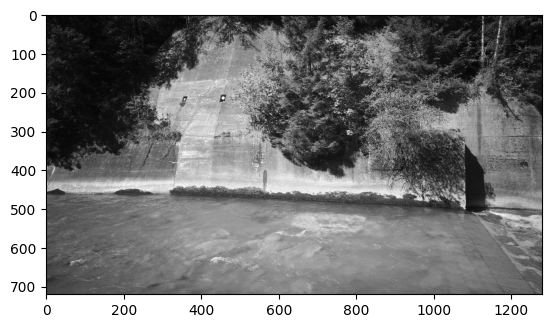

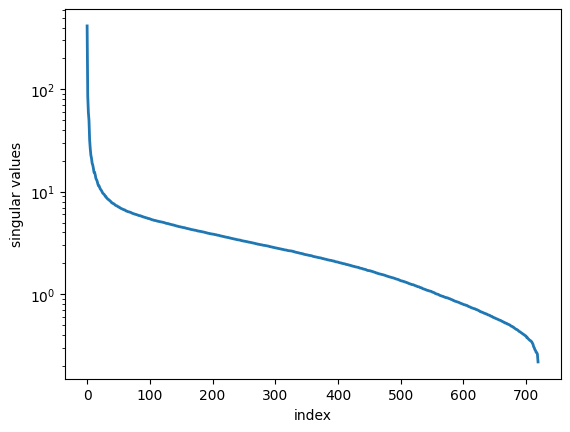

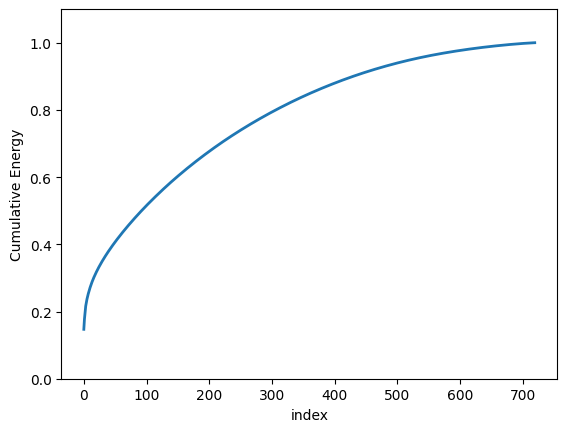

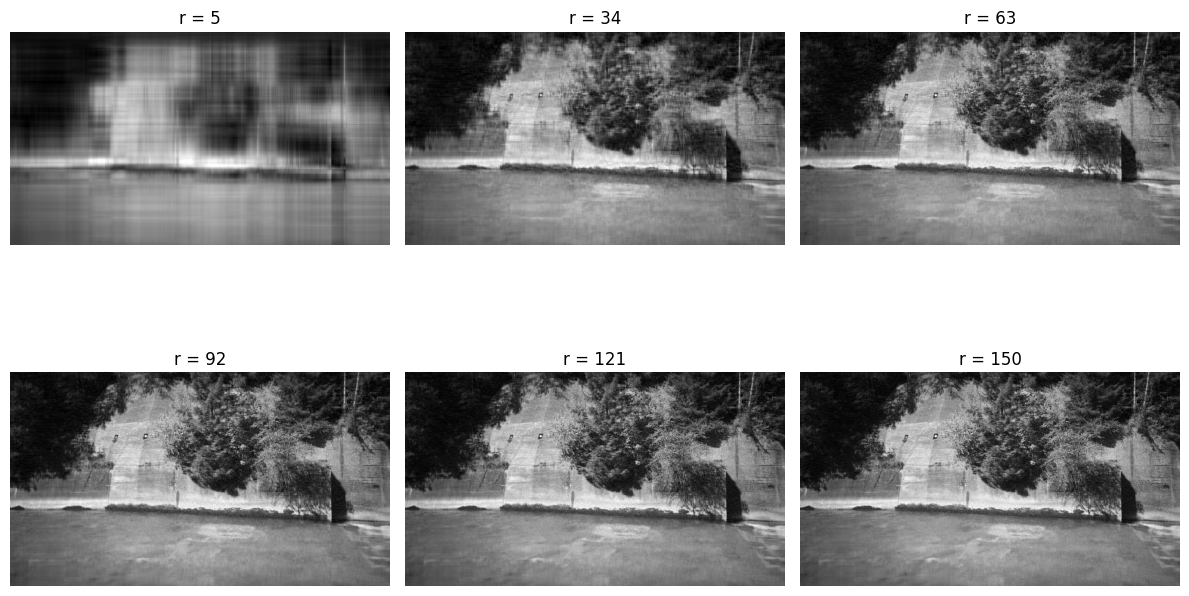

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg


def rgb2gray(rgb):
    return np.dot(rgb[..., :3], [0.2989, 0.5870, 0.1140])


img = mpimg.imread("fig.png")
X = rgb2gray(img)
plt.imshow(X, cmap="gray", vmin=0, vmax=1)

# SINGULAR VALUES
U, S, Vh = np.linalg.svd(X, full_matrices=True)
fig, ax = plt.subplots()
ax.set_xlabel("index")
ax.set_ylabel("singular values")
plt.semilogy()
ax.plot(S, lw=2)

# CUMULATIVE ENERGY
CumEn = np.cumsum(S) / np.sum(S)
fig, ax = plt.subplots()
ax.set_xlabel("index")
ax.set_ylabel("Cumulative Energy")
ax.set_ylim([0, 1.1])
ax.plot(CumEn, lw=2)

# COMPRESSED IMAGE
R = np.linspace(5, 150, 6, dtype=int)
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.ravel()

for i, r in enumerate(R):
    U_tilde = U[:, :r]
    S_tilde = S[:r]
    Vh_tilde = Vh[:r, :]

    X_tilde = U_tilde @ np.diag(S_tilde) @ Vh_tilde

    axes[i].imshow(X_tilde, cmap="gray", vmin=0, vmax=1)
    axes[i].set_title(f"r = {r}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()
